#### Imports and Setups

In [1]:
import pandas as pd
from dotenv import load_dotenv
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

from rich.console import Console
from rich.pretty import Pretty
from rich.theme import Theme

theme = Theme(
    {
        "json.key": "#c1a2ff",
        "json.string": "#FCCEA1",
        "json.number": "#A1C4FD",
        "json.boolean": "#A6F5D8",
        "json.null": "#ffb3ba",
    }
)

console = Console(
    theme=theme,
    force_terminal=True,
    force_jupyter=False,
    color_system="truecolor",
)
load_dotenv()

True

#### Model

In [2]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7,
    max_output_tokens=500,
)


#### State

In [3]:
class LoanState(TypedDict):
    name: str
    age: int
    employment_years: int
    monthly_income: int
    credit_score: int
    loan_amount: int

    eligibility_status: Literal["Eligible", "Not Eligible"]
    credit_score_category: Literal["S", "A", "B", "C", "NA"]
    risk_category: Literal["Low", "Medium", "High", "NA"]
    approval_status: Literal["Approve", "Review", "Reject"]

#### Node & Helper Functions

In [4]:
# check eligibility
def evaluate_eligibility(state: LoanState):
    if state["age"] >= 21 and state["employment_years"] >= 2:
        return {"eligibility_status": "Eligible"}
    else:
        return {
            "eligibility_status": "Not Eligible",
            "credit_score_category": "NA",
            "risk_category": "NA",
        }


# eligibility routing
def eligilibility_routing(state: LoanState) -> Literal["evaluate_credit_score", "reject_loan"]:
    if state["eligibility_status"] == "Eligible":
        return "evaluate_credit_score"
    else:
        return "reject_loan"


# calculate credit score
def evaluate_credit_score(state: LoanState):
    if state["credit_score"] >= 750:
        return {"credit_score_category": "S"}
    elif state["credit_score"] >= 650:
        return {"credit_score_category": "A"}
    elif state["credit_score"] >= 550:
        return {"credit_score_category": "B"}
    else:
        return {"credit_score_category": "C"}


# calculate risk ratio
def evaluate_risk(state: LoanState):
    risk_ratio = state["loan_amount"] / state["monthly_income"]
    if risk_ratio <= 0.3:
        return {"risk_category": "Low"}
    elif risk_ratio <= 0.6:
        return {"risk_category": "Medium"}
    else:
        return {"risk_category": "High"}


# approval routing
def approval_routing(state: LoanState) -> Literal["approve_loan", "reject_loan", "review_loan"]:
    if state["credit_score_category"] == "S" and state["risk_category"] == "Low":
        return "approve_loan"
    elif state["credit_score_category"] == "C" or state["risk_category"] == "High":
        return "reject_loan"
    else:
        return "review_loan"


# approve loan
def approve_loan(state: LoanState):
    return {"approval_status": "Approve"}


# review loan
def review_loan(state: LoanState):
    return {"approval_status": "Review"}


# reject loan
def reject_loan(state: LoanState):
    return {"approval_status": "Reject"}

#### Init Graph

In [5]:
graph = StateGraph(LoanState)

#### Add Nodes

In [6]:
graph.add_node("evaluate_eligibility", evaluate_eligibility)
graph.add_node("evaluate_credit_score", evaluate_credit_score)
graph.add_node("evaluate_risk", evaluate_risk)
graph.add_node("approve_loan", approve_loan)
graph.add_node("reject_loan", reject_loan)
graph.add_node("review_loan", reject_loan)

#### Add Edges

In [7]:
graph.add_edge(START, "evaluate_eligibility")
graph.add_conditional_edges("evaluate_eligibility", eligilibility_routing)

graph.add_edge("evaluate_credit_score", "evaluate_risk")
graph.add_conditional_edges("evaluate_risk", approval_routing)

graph.add_edge("approve_loan", END)
graph.add_edge("reject_loan", END)
graph.add_edge("review_loan", END)

#### Compilation

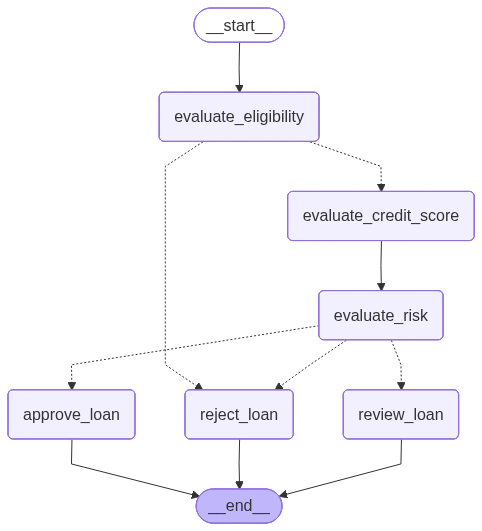

In [8]:
workflow = graph.compile()
workflow

#### Ingest Data

In [9]:
df = pd.read_csv("./files/loan_applications.csv")
df

,name,age,employment_years,monthly_income,credit_score,loan_amount
0,Rahul Sharma,30,5,100000,800,20000
1,Priya Patel,28,3,100000,680,50000
2,Amit Verma,35,7,100000,500,10000
3,Rohan Singh,19,1,50000,850,10000
4,Neha Gupta,32,4,50000,780,100000
5,Karan Mehta,26,2,70000,720,25000
6,Sneha Joshi,29,6,120000,790,30000
7,Vikas Rao,40,10,150000,640,60000
8,Anjali Kulkarni,24,2,60000,560,15000
9,Manoj Desai,45,15,200000,810,50000


#### Execution

In [10]:
final_states = []
for row in df.iloc:
    final_state = workflow.invoke(row.to_dict())
    final_states.append(final_state)


In [11]:
loan_application_status_df = pd.DataFrame(final_states)
loan_application_status_df.to_csv("./files/loan_application_status.csv", encoding="utf-8")
loan_application_status_df

,name,age,employment_years,monthly_income,credit_score,loan_amount,eligibility_status,credit_score_category,risk_category,approval_status
0,Rahul Sharma,30,5,100000,800,20000,Eligible,S,Low,Approve
1,Priya Patel,28,3,100000,680,50000,Eligible,A,Medium,Reject
2,Amit Verma,35,7,100000,500,10000,Eligible,C,Low,Reject
3,Rohan Singh,19,1,50000,850,10000,Not Eligible,NA,NA,Reject
4,Neha Gupta,32,4,50000,780,100000,Eligible,S,High,Reject
5,Karan Mehta,26,2,70000,720,25000,Eligible,A,Medium,Reject
6,Sneha Joshi,29,6,120000,790,30000,Eligible,S,Low,Approve
7,Vikas Rao,40,10,150000,640,60000,Eligible,B,Medium,Reject
8,Anjali Kulkarni,24,2,60000,560,15000,Eligible,B,Low,Reject
9,Manoj Desai,45,15,200000,810,50000,Eligible,S,Low,Approve
